# Inverse Heat Transfer with Automatic Differentiation

In this tutorial, you will learn how to:

1. Build a Tesseract that wraps a forward model written in plain **Fortran**, whose
   derivatives are generated automatically by [Enzyme](https://enzyme.mit.edu/) at
   the LLVM IR level -- with no hand-written adjoint code and no source
   modifications.
2. Bridge the Fortran solver into JAX with
   [`tesseract-jax`](https://github.com/pasteurlabs/tesseract-jax), so that it
   behaves as an ordinary differentiable JAX function.
3. Verify the resulting gradients against an independently derived analytic
   gradient.
4. Use the gradients to solve a 900-parameter inverse heat-transfer problem with
   `scipy.optimize`.

## Context

Inverse heat-transfer problems arise across engineering: reconstructing an unknown
initial temperature distribution, a heat source, or a boundary condition from a
limited set of later measurements. These problems are typically ill-posed and
high-dimensional, which makes gradient-based optimization the practical approach --
provided gradients of the forward solver are available.

The forward model here is a 2D transient heat-conduction solver written in plain
Fortran. Many established scientific solvers are written in Fortran or C and were
never designed to be differentiable, so obtaining gradients usually means writing
and maintaining adjoint code by hand. Enzyme avoids this by differentiating the
compiled LLVM IR directly: it synthesizes forward- and reverse-mode derivatives
from the solver as built, without source changes.

Wrapped as a [Tesseract](https://github.com/pasteurlabs/tesseract-core) and bridged
into JAX with `tesseract-jax`, the Fortran solver becomes an ordinary differentiable
JAX function, so `jax.grad` flows through it like any other JAX operation. The
optimizer in this notebook only ever interacts with a JAX function; the underlying
solver and its differentiation are encapsulated behind the Tesseract.

## Step 1: Build and serve the Enzyme AD Tesseract

The build compiles the Fortran source to LLVM IR with LFortran, runs the Enzyme
AD pass to synthesize forward- and reverse-mode derivatives, and links everything
into a shared library -- all inside the container. This step downloads the LLVM 19
toolchain and builds Enzyme from source, so the first build takes a few minutes.

In [1]:
%%bash
# Render the build status statically instead of an animated progress
# spinner, which streams as noise in captured notebook output.
export TERM=dumb
tesseract build .

 [i] Building image ...
 [i] Built image sha256:0172263cf380, ['enzyme-thermal-2d:1.0.0', 'enzyme-thermal-2d:latest']


["enzyme-thermal-2d:1.0.0", "enzyme-thermal-2d:latest"]


In [2]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tesseract_jax import apply_tesseract

from tesseract_core import Tesseract

# JAX needs float64 to match the Fortran solver's double precision.
jax.config.update("jax_enable_x64", True)

# Serve the Tesseract; it stays alive for the rest of the notebook.
enzyme_tess = Tesseract.from_image("enzyme-thermal-2d")
enzyme_tess.serve()

In [3]:
# Grid and simulation parameters (fixed throughout)
nx, ny = 30, 30
n = nx * ny
n_steps = 500
dt = 0.05  # 500 steps x 0.05s = 25s (CFL-safe up to k0 ~ 80)
Lx, Ly = 0.1, 0.05

# Fixed physical parameters
rho = 7850.0  # density [kg/m^3] (mild steel)
cp = 460.0  # specific heat [J/(kg*K)]
h_conv = 25.0  # convection coefficient [W/(m^2*K)]
T_inf = 293.15  # ambient temperature [K]
T_hot = 373.15  # hot wall temperature [K]

# Initial condition: uniform ambient temperature
T_init = np.full(n, T_inf)
Q = np.zeros(n)  # no internal heating

rng = np.random.default_rng(42)  # reproducible noise

# Figures are written here (gitignored); copy into docs/static/blog/
# as enzyme-<name>.png by hand when updating the blog post.
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Simulation: {n_steps} steps x {dt}s = {n_steps * dt:.0f}s total")

Simulation: 500 steps x 0.05s = 25s total


## Step 2: Verify the gradients against an analytic derivative

Before using the gradients in an optimizer, we check them against a derivative we
can compute *independently*, without Enzyme anywhere in the loop.

For one regime we can do exactly that. Setting the conductivity's temperature
coefficient $k_1 = 0$ makes the solver linear: each explicit step is an affine map
of the temperature field, $T^{s+1} = A(k_0)\,T^s + c(k_0)$, where the operators $A$
and $c$ encode the stencil and the mixed boundary conditions and depend affinely on
$k_0$. This structure gives the exact derivative of the whole multi-step trajectory
via the tangent recurrence

$$\frac{\partial T^{s+1}}{\partial k_0} = A_1\,T^s + A(k_0)\,\frac{\partial T^s}{\partial k_0} + c_1,$$

which we iterate in plain NumPy. We recover $A$ and $c$ by probing the solver at
two stable $k_0$ values (the map is exactly affine in $k_0$, so any two recover it
with no truncation error), confirm the reconstruction reproduces the solver's
trajectory to roundoff, then compare the analytic gradient against Enzyme's VJP.
For reference, we also include a finite-difference estimate swept over step size,
which agrees with the analytic gradient only to limited accuracy.

Recovering affine map at k0=45.0 (900 probes)...
Recovering affine map at k0=40.0 (900 probes)...
affine-model vs solver trajectory rel err = 1.13e-14
analytic gradient = 2.4101518794e+02
enzyme   gradient = 2.4101518794e+02
Enzyme rel err vs analytic = 5.63e-12


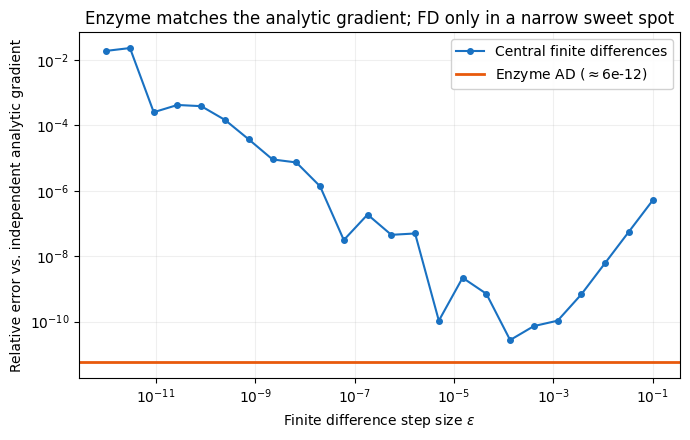

In [4]:
# --- Independent analytic-gradient benchmark (linear regime, k1 = 0) ---
k0_bench = 45.0  # CFL r ~ 0.26; both probe values must keep r < 0.5
coef = dt / (rho * cp)


def _bench_inputs(k0, n_steps_, field):
    return {
        "T_init": jnp.asarray(field),
        "Q": jnp.asarray(Q),
        "nx": nx,
        "ny": ny,
        "n_steps": n_steps_,
        "k0": jnp.float64(k0),
        "k1": jnp.float64(0.0),  # linear regime
        "rho": jnp.float64(rho),
        "cp": jnp.float64(cp),
        "h_conv": jnp.float64(h_conv),
        "T_inf": jnp.float64(T_inf),
        "T_hot": jnp.float64(T_hot),
        "Lx": jnp.float64(Lx),
        "Ly": jnp.float64(Ly),
        "dt": jnp.float64(dt),
    }


def _step(field, k0):
    """One explicit solver step from `field` at conductivity k0."""
    out = apply_tesseract(enzyme_tess, _bench_inputs(k0, 1, field))["T_final"]
    return np.asarray(out, dtype=np.float64)


def _affine_map(k0):
    """Recover U(T;k0) = A T + c via unit probes (n+1 solver calls)."""
    c = _step(np.zeros(n), k0)
    A = np.zeros((n, n))
    for j in range(n):
        e = np.zeros(n)
        e[j] = 1.0
        A[:, j] = _step(e, k0) - c
    return A, c


# Non-uniform initial field so the gradient is non-degenerate.
xb, yb = np.linspace(0, Lx, nx), np.linspace(0, Ly, ny)
XXb, YYb = np.meshgrid(xb, yb)
T_init_bench = (
    T_inf + 40.0 * np.sin(np.pi * XXb / Lx) * np.sin(np.pi * YYb / Ly)
).ravel()

ka, kb = 45.0, 40.0
print(f"Recovering affine map at k0={ka} ({n} probes)...")
Aa, ca = _affine_map(ka)
print(f"Recovering affine map at k0={kb} ({n} probes)...")
Ab, cb = _affine_map(kb)

A1 = (Aa - Ab) / (ka - kb)
A0 = Aa - ka * A1
c1 = (ca - cb) / (ka - kb)
c0 = ca - ka * c1
A = A0 + k0_bench * A1
c = c0 + k0_bench * c1

# Exact tangent recurrence over the full 500-step trajectory (pure NumPy).
T = T_init_bench.copy()
dT = np.zeros(n)
for _ in range(n_steps):
    dT = A1 @ T + A @ dT + c1
    T = A @ T + c
analytic = float(np.sum(dT))

# Consistency check: does the affine model match the solver's real trajectory?
T_solver = np.asarray(
    apply_tesseract(enzyme_tess, _bench_inputs(k0_bench, n_steps, T_init_bench))[
        "T_final"
    ],
    dtype=np.float64,
)
traj_rel = np.linalg.norm(T - T_solver) / np.linalg.norm(T_solver)
print(f"affine-model vs solver trajectory rel err = {traj_rel:.2e}")

# Enzyme VJP of the same scalar (cotangent = ones).
vjp = enzyme_tess.vector_jacobian_product(
    inputs=_bench_inputs(k0_bench, n_steps, T_init_bench),
    vjp_inputs=["k0"],
    vjp_outputs=["T_final"],
    cotangent_vector={"T_final": np.ones(n)},
)
enzyme_grad = float(vjp["k0"])
enzyme_err = abs(enzyme_grad - analytic) / (abs(analytic) + 1e-30)
print(f"analytic gradient = {analytic:.10e}")
print(f"enzyme   gradient = {enzyme_grad:.10e}")
print(f"Enzyme rel err vs analytic = {enzyme_err:.2e}")

# Central finite differences vs the same analytic reference, swept over step size.
epsilons = np.logspace(-1, -12, 24)
fd_err = []
for eps in epsilons:
    Tp = np.asarray(
        apply_tesseract(
            enzyme_tess, _bench_inputs(k0_bench + eps, n_steps, T_init_bench)
        )["T_final"]
    )
    Tm = np.asarray(
        apply_tesseract(
            enzyme_tess, _bench_inputs(k0_bench - eps, n_steps, T_init_bench)
        )["T_final"]
    )
    fd = np.sum(Tp - Tm) / (2 * eps)
    fd_err.append(abs(fd - analytic) / (abs(analytic) + 1e-30))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
ax.loglog(
    epsilons, fd_err, "o-", ms=4, color="#1971c2", label="Central finite differences"
)
ax.axhline(
    enzyme_err, color="#e8590c", lw=2, label=f"Enzyme AD ($\\approx${enzyme_err:.0e})"
)
ax.set_xlabel("Finite difference step size $\\epsilon$")
ax.set_ylabel("Relative error vs. independent analytic gradient")
ax.set_title("Enzyme matches the analytic gradient; FD only in a narrow sweet spot")
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "analytic_benchmark.png", dpi=180, bbox_inches="tight")
plt.show()

## Step 3: Inverse problem -- recovering a hidden heat signature (900 parameters)

Suppose a steel plate was subjected to an unmonitored heating event -- for example
a laser pulse or a localized defect generating heat. Five seconds later, we measure
temperatures at 100 sensor locations and want to reconstruct the initial temperature
distribution.

This is an ill-posed inverse problem: 900 unknowns (the temperature at every grid
cell) inferred from 100 noisy observations, through a nonlinear PDE. We add a small
Tikhonov term that penalizes departure from the ambient prior, which regularizes the
problem; the optimizer is a standard `jax.value_and_grad` + L-BFGS-B loop over all
900 unknowns. This is a setting where reverse-mode AD is essential rather than
merely convenient:

| Method | Forward solves per iteration |
|--------|----------------------------:|
| Finite differences | 901 (N+1) |
| Reverse-mode AD | 2 (forward + reverse) |
| **Speedup** | **~450×** |

Finite differences would need 901 forward solves every iteration to assemble all
900 gradients; one reverse sweep returns them all for roughly the cost of two
forward passes. The Tikhonov term is just another addition to the JAX loss, which
`jax.value_and_grad` differentiates along with the rest.

In [5]:
# --- Forensics setup ---
# Shorter simulation: 5 seconds (we want residual structure in the initial field)
n_steps_p2 = 100
dt_p2 = 0.05

# Fixed material properties (known — we're recovering T_init, not k)
k0_p2 = 45.0
k1_p2 = -0.01

# Build coordinate arrays for the 30x30 grid
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)
X_flat, Y_flat = X.flatten(), Y.flatten()

# True initial temperature: two Gaussian hot spots on a warm background
T_init_true = (
    T_inf
    + 40.0 * np.exp(-((X_flat - 0.04) ** 2 + (Y_flat - 0.025) ** 2) / 0.015**2)
    + 25.0 * np.exp(-((X_flat - 0.08) ** 2 + (Y_flat - 0.035) ** 2) / 0.01**2)
)


def make_inputs_p2(T_init_field):
    """Inputs for the forensics problem; T_init_field is the differentiable unknown."""
    return {
        "T_init": jnp.asarray(T_init_field),
        "Q": jnp.asarray(Q),
        "nx": nx,
        "ny": ny,
        "n_steps": n_steps_p2,
        "k0": jnp.float64(k0_p2),
        "k1": jnp.float64(k1_p2),
        "rho": jnp.float64(rho),
        "cp": jnp.float64(cp),
        "h_conv": jnp.float64(h_conv),
        "T_inf": jnp.float64(T_inf),
        "T_hot": jnp.float64(T_hot),
        "Lx": jnp.float64(Lx),
        "Ly": jnp.float64(Ly),
        "dt": jnp.float64(dt_p2),
    }


def solve_p2(T_init_field):
    return apply_tesseract(enzyme_tess, make_inputs_p2(T_init_field))["T_final"]


# Run forward simulation with the true initial field
T_final_true_p2 = np.asarray(solve_p2(T_init_true))

# 10x10 sensor grid (100 sensors in the interior)
sensor_ix_p2 = np.linspace(3, nx - 4, 10, dtype=int)
sensor_jy_p2 = np.linspace(3, ny - 4, 10, dtype=int)
sensor_grid = np.array([(jy * nx + ix) for jy in sensor_jy_p2 for ix in sensor_ix_p2])
n_sensors_p2 = len(sensor_grid)

# Observed data: true final temperatures at sensors + noise
noise_std_p2 = 0.3  # K
T_obs_p2 = T_final_true_p2[sensor_grid] + rng.normal(0, noise_std_p2, n_sensors_p2)

print(f"Grid: {nx}x{ny} = {n} unknowns")
print(f"Sensors: {n_sensors_p2}")
print(f"Simulation: {n_steps_p2} steps x {dt_p2}s = {n_steps_p2 * dt_p2:.0f}s")
print(f"True T_init range: {T_init_true.min():.1f} — {T_init_true.max():.1f} K")

Grid: 30x30 = 900 unknowns
Sensors: 100
Simulation: 100 steps x 0.05s = 5s
True T_init range: 293.2 — 332.7 K


In [6]:
import time

from scipy.optimize import minimize

T_obs_p2_jax = jnp.asarray(T_obs_p2)
sensor_grid_jax = jnp.asarray(sensor_grid)

# Tikhonov regularization weight: penalizes departure from the ambient prior,
# which stabilizes this ill-posed problem (900 unknowns, 100 observations).
alpha_reg = 1e-4


def loss_fn_p2(T_init_vec):
    """Regularized sensor-misfit loss for the 900-element initial field. Pure JAX."""
    T_pred = solve_p2(T_init_vec)
    residuals = T_pred[sensor_grid_jax] - T_obs_p2_jax
    data_loss = 0.5 * jnp.sum(residuals**2)
    reg_loss = 0.5 * alpha_reg * jnp.sum((T_init_vec - T_inf) ** 2)
    return data_loss + reg_loss


value_and_grad_p2 = jax.jit(jax.value_and_grad(loss_fn_p2))

# warm up JIT
_ = value_and_grad_p2(jnp.asarray(T_init))


def scipy_objective_p2(T_init_vec):
    loss, grad = value_and_grad_p2(jnp.asarray(T_init_vec))
    return float(loss), np.asarray(grad, dtype=np.float64)


# Start from uniform ambient (the wrong answer)
T_init_guess = np.full(n, T_inf)
loss_history_p2 = []

iter_count = [0]
t_start = time.time()


def callback_p2(x):
    iter_count[0] += 1
    if iter_count[0] % 10 == 0:
        loss, _ = scipy_objective_p2(x)
        loss_history_p2.append(loss)
        elapsed = time.time() - t_start
        print(f"  iter {iter_count[0]:3d}: loss={loss:.4f}, elapsed={elapsed:.1f}s")


loss0_p2 = scipy_objective_p2(T_init_guess)[0]
loss_history_p2.append(loss0_p2)
print(f"Initial loss: {loss0_p2:.2f}")
print(f"Running L-BFGS-B with {n} parameters...")

result_p2 = minimize(
    fun=scipy_objective_p2,
    x0=T_init_guess,
    method="L-BFGS-B",
    jac=True,
    bounds=[(250.0, 450.0)] * n,
    callback=callback_p2,
    options={"maxiter": 200, "ftol": 1e-15, "gtol": 1e-10},
)

elapsed_total = time.time() - t_start
loss_final = scipy_objective_p2(result_p2.x)[0]
loss_history_p2.append(loss_final)
T_init_recovered = result_p2.x

print(f"\nOptimization finished: {result_p2.nit} iterations, {elapsed_total:.1f}s")
print(f"Loss: {loss0_p2:.2f} → {loss_final:.4f}")
print(f"T_init correlation: {np.corrcoef(T_init_true, T_init_recovered)[0, 1]:.4f}")
print("\nCost comparison per iteration:")
print(
    f"  Finite differences: {n + 1} forward solves = "
    f"~{(n + 1) * elapsed_total / result_p2.nfev:.1f}s"
)
print(
    f"  Reverse-mode AD:    2 solves (fwd+rev)   = "
    f"~{2 * elapsed_total / result_p2.nfev:.2f}s"
)

Initial loss: 4085.86
Running L-BFGS-B with 900 parameters...
  iter  10: loss=8.0931, elapsed=0.4s
  iter  20: loss=7.5007, elapsed=0.8s
  iter  30: loss=7.4350, elapsed=1.2s
  iter  40: loss=7.4246, elapsed=1.7s
  iter  50: loss=7.4222, elapsed=2.0s
  iter  60: loss=7.4216, elapsed=2.4s
  iter  70: loss=7.4215, elapsed=2.8s
  iter  80: loss=7.4215, elapsed=3.2s
  iter  90: loss=7.4215, elapsed=3.5s
  iter 100: loss=7.4215, elapsed=3.8s
  iter 110: loss=7.4215, elapsed=4.2s
  iter 120: loss=7.4215, elapsed=4.5s
  iter 130: loss=7.4215, elapsed=4.9s
  iter 140: loss=7.4215, elapsed=5.3s
  iter 150: loss=7.4215, elapsed=5.6s
  iter 160: loss=7.4215, elapsed=6.0s
  iter 170: loss=7.4215, elapsed=6.3s
  iter 180: loss=7.4215, elapsed=6.7s

Optimization finished: 187 iterations, 8.4s
Loss: 4085.86 → 7.4215
T_init correlation: 0.9804

Cost comparison per iteration:
  Finite differences: 901 forward solves = ~30.5s
  Reverse-mode AD:    2 solves (fwd+rev)   = ~0.07s


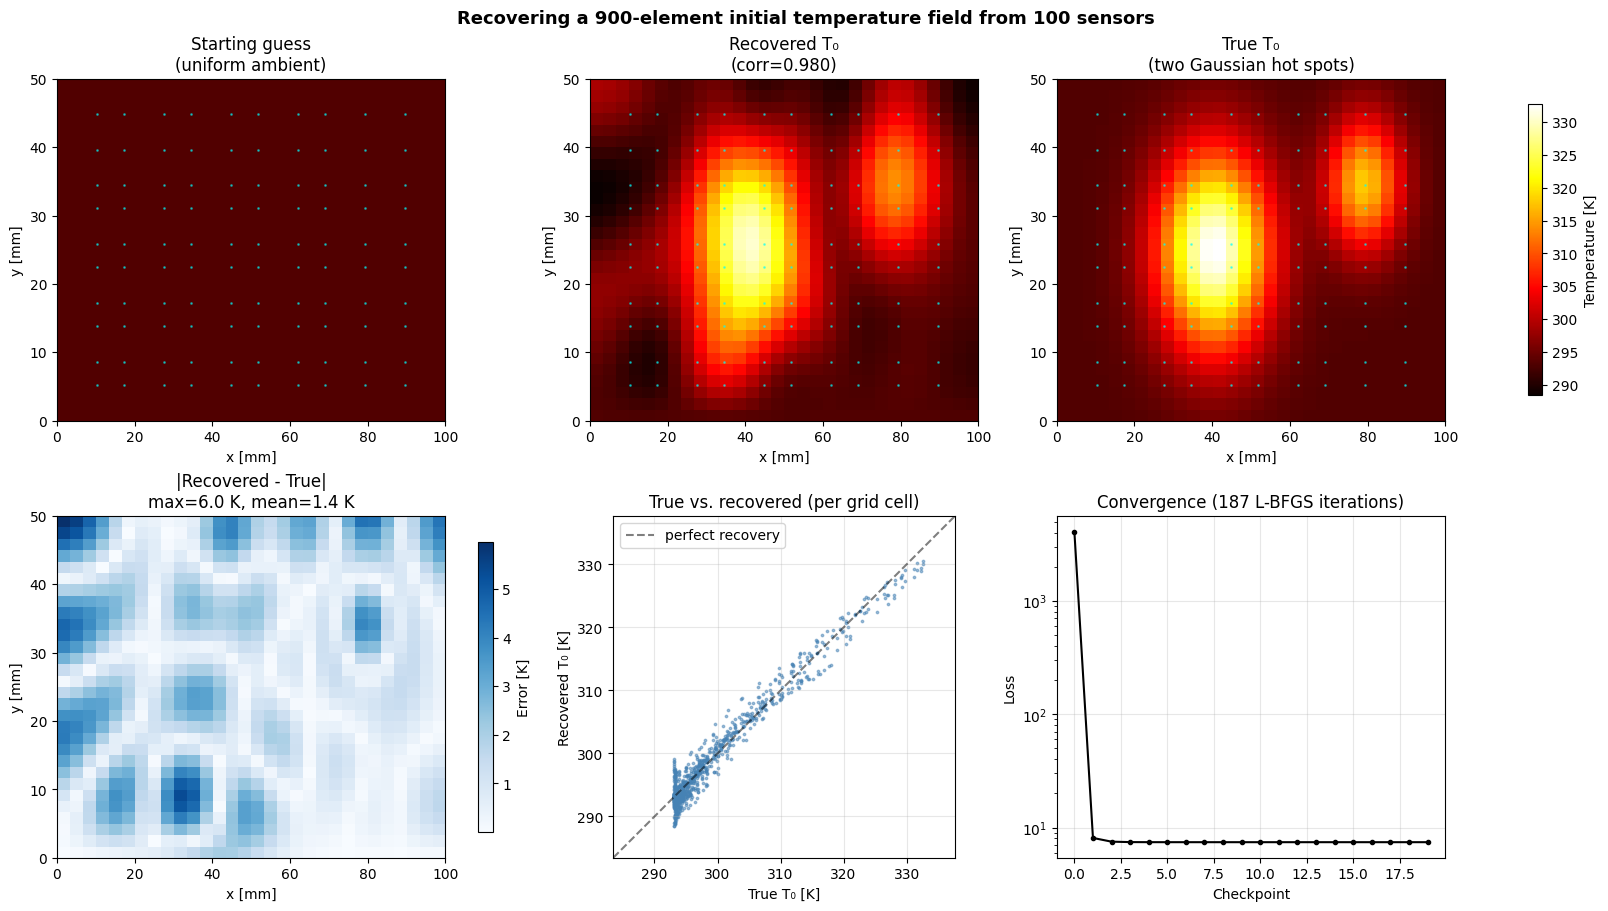

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), layout="constrained")

extent = [0, Lx * 1e3, 0, Ly * 1e3]

# --- Top row: initial temperature fields ---
vmin_init = min(T_init_true.min(), T_init_recovered.min(), T_inf)
vmax_init = max(T_init_true.max(), T_init_recovered.max())

axes[0, 0].imshow(
    T_init_guess.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 0].set_title("Starting guess\n(uniform ambient)")

axes[0, 1].imshow(
    T_init_recovered.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 1].set_title(
    f"Recovered T₀\n(corr={np.corrcoef(T_init_true, T_init_recovered)[0, 1]:.3f})"
)

im_true = axes[0, 2].imshow(
    T_init_true.reshape(ny, nx),
    origin="lower",
    cmap="hot",
    extent=extent,
    aspect="auto",
    vmin=vmin_init,
    vmax=vmax_init,
)
axes[0, 2].set_title("True T₀\n(two Gaussian hot spots)")

plt.colorbar(im_true, ax=axes[0, :].tolist(), label="Temperature [K]", shrink=0.85)

# Mark sensor locations on all top-row plots
for ax in axes[0, :]:
    for jy_idx in sensor_jy_p2:
        for ix_idx in sensor_ix_p2:
            x_mm = ix_idx / (nx - 1) * Lx * 1e3
            y_mm = jy_idx / (ny - 1) * Ly * 1e3
            ax.plot(x_mm, y_mm, ".", color="cyan", markersize=2, alpha=0.5)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")

# --- Bottom row: diagnostics ---
error_p2 = np.abs(T_init_recovered - T_init_true).reshape(ny, nx)
im_err = axes[1, 0].imshow(
    error_p2, origin="lower", cmap="Blues", extent=extent, aspect="auto"
)
axes[1, 0].set_title(
    f"|Recovered - True|\nmax={error_p2.max():.1f} K, mean={error_p2.mean():.1f} K"
)
axes[1, 0].set_xlabel("x [mm]")
axes[1, 0].set_ylabel("y [mm]")
plt.colorbar(im_err, ax=axes[1, 0], label="Error [K]", shrink=0.85)

axes[1, 1].scatter(T_init_true, T_init_recovered, s=3, alpha=0.5, c="steelblue")
lims = [vmin_init - 5, vmax_init + 5]
axes[1, 1].plot(lims, lims, "k--", alpha=0.5, label="perfect recovery")
axes[1, 1].set_xlim(lims)
axes[1, 1].set_ylim(lims)
axes[1, 1].set_xlabel("True T₀ [K]")
axes[1, 1].set_ylabel("Recovered T₀ [K]")
axes[1, 1].set_title("True vs. recovered (per grid cell)")
axes[1, 1].legend()
axes[1, 1].set_aspect("equal")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].semilogy(loss_history_p2, "k.-", linewidth=1.5)
axes[1, 2].set_xlabel("Checkpoint")
axes[1, 2].set_ylabel("Loss")
axes[1, 2].set_title(f"Convergence ({result_p2.nit} L-BFGS iterations)")
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(
    "Recovering a 900-element initial temperature field from 100 sensors",
    fontsize=13,
    fontweight="bold",
)
fig.savefig(FIGURE_DIR / "thermal_forensics.png", dpi=180, bbox_inches="tight")
plt.show()

## Takeaways

Each `jax.value_and_grad` call above triggered the following chain:

| Layer | Technology | Role |
|-------|-----------|------|
| Optimizer | SciPy L-BFGS-B | Quasi-Newton update loop |
| AD framework | JAX reverse-mode | Propagates cotangents |
| Tesseract bridge | `tesseract-jax` | Registers JAX primitive, dispatches HTTP calls |
| Transport | HTTP + JSON | Crosses the process/container boundary |
| AD engine | Enzyme (LLVM pass) | Generates the VJP from compiled Fortran IR |
| Solver | Fortran 90 | `thermal_2d_solve` |

1. **Compiled Fortran can participate in end-to-end AD.** The forward solver is
   plain Fortran and was never modified. Enzyme differentiated it from the compiled
   LLVM IR, and Tesseract made it callable -- and differentiable -- from JAX.

2. **No hand-coded adjoints.** Both the forward- and reverse-mode derivatives are
   synthesized by the Enzyme pass, rather than derived and maintained by hand.

3. **The gradients are verifiable.** In the linear regime, Enzyme's VJP matches an
   independently derived analytic gradient to roundoff.

4. **Reverse-mode AD scales to high-dimensional inverse problems.** The same
   `jax.value_and_grad` call returns all 900 gradient components from a single
   reverse sweep, which is what makes the 900-parameter reconstruction tractable.

### What's next

- **Change the forward model.** Edit the Fortran source and rebuild; Enzyme
  regenerates the derivatives with no adjoint code to update.
- **Try a different inverse problem.** Recover a boundary condition or a heat
  source instead of the initial field, or vary the number and placement of sensors.
- **Swap in a different optimizer.** Replace L-BFGS-B with any other
  `scipy.optimize` or `optax` optimizer to compare convergence behavior.
- **Explore other demos.** See the [CFD optimization](cfd-optimization.ipynb),
  [data assimilation](data-assimilation.ipynb), and
  [FEM shape optimization](fem-shape-optimization.ipynb) demos for other ways to
  compose Tesseracts with JAX.

Questions? Feedback? Please reach out through the [Tesseract Community Forum](https://si-tesseract.discourse.group/).